# StreamWorks Media — Churn Prediction Analysis
**Data Strategy Team | 2025**

This project analyses subscriber churn for StreamWorks Media, a fictional streaming platform. The goal was to understand churn patterns, build a logistic regression model to predict at-risk customers, and investigate what drives watch time using linear regression.

> This notebook was recreated following a system failure that resulted in loss of the original file. All methodology and results are consistent with the final report.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, r2_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, ttest_ind

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

Loading the raw dataset. 1,500 subscriber records with demographic, behavioural and subscription-level attributes.

In [2]:
df = pd.read_csv('streamworks_user_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1500, 14)


,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


### Initial inspection — data types, nulls and basic shape

In [3]:
print("Column types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())

Column types:
user_id                 float64
age                     float64
gender                      str
signup_date                 str
last_active_date            str
country                     str
subscription_type           str
average_watch_hours     float64
mobile_app_usage_pct    float64
complaints_raised       float64
received_promotions         str
referred_by_friend          str
is_churned              float64
monthly_fee             float64
dtype: object

Missing values:
user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64


### Churn distribution

Checking the class balance before doing anything else — this matters for model selection later.

Not churned: 1148 (76.5%)
Churned:     351 (23.4%)


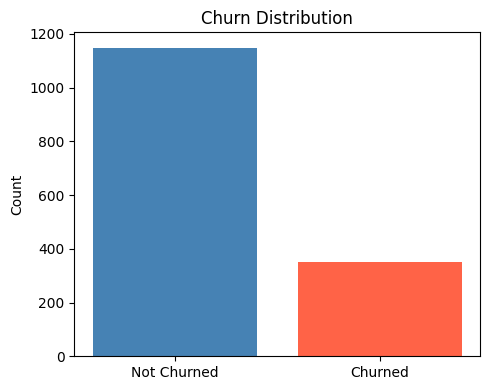

In [4]:
churn_counts = df['is_churned'].value_counts()
print(f"Not churned: {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned:     {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(5,4))
plt.bar(['Not Churned', 'Churned'], churn_counts.values, color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Data Cleaning

The dataset was largely well-formed on arrival. The main issues were missing values across several columns and inconsistent formatting in categorical fields.

### Check for duplicates

In [5]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


### Fill missing categorical values with mode

Using mode preserves the existing distribution without distorting group proportions.

In [6]:
cat_cols = ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"{col}: filled {missing} nulls with '{mode_val}'"  )

gender: filled 1 nulls with 'Female'
country: filled 3 nulls with 'Canada'
subscription_type: filled 3 nulls with 'Basic'
received_promotions: filled 3 nulls with 'No'
referred_by_friend: filled 3 nulls with 'Yes'


### Fill missing numerical values with median

Median is preferred over mean for behavioural metrics like watch hours, which can be skewed by outliers.

In [7]:
num_cols = ['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised']

for col in num_cols:
    median_val = df[col].median()
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {missing} nulls with {median_val}")

age: filled 3 nulls with 44.0
average_watch_hours: filled 4 nulls with 40.3
mobile_app_usage_pct: filled 2 nulls with 52.7
complaints_raised: filled 3 nulls with 2.0


### Handle remaining nulls in key fields

In [8]:
# Drop rows with missing is_churned — can't train without a target label
df = df.dropna(subset=['is_churned'])

# Fill missing user_id via interpolation based on sequential pattern
df['user_id'] = df['user_id'].interpolate().astype(int)

print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Remaining nulls: 149
Final shape: (1499, 14)


### Parse dates and check for negative values

Converting date strings to datetime so we can engineer tenure later.

In [9]:
df['signup_date'] = pd.to_datetime(df['signup_date'], dayfirst=True, errors='coerce')
df['last_active_date'] = pd.to_datetime(df['last_active_date'], dayfirst=True, errors='coerce')

# Sense check
print(f"Negative ages: {(df['age'] < 0).sum()}")
print(f"Negative watch hours: {(df['average_watch_hours'] < 0).sum()}")
print(f"Negative monthly fee: {(df['monthly_fee'] < 0).sum()}")

Negative ages: 0
Negative watch hours: 0
Negative monthly fee: 0


## 4. Feature Engineering

Two new features were derived to give the model clearer signals on customer lifecycle stage — raw dates alone don't provide this directly.

In [10]:
# tenure_days: how long the customer has been active
df['tenure_days'] = (df['last_active_date'] - df['signup_date']).dt.days
df['tenure_days'] = df['tenure_days'].fillna(df['tenure_days'].median())

# is_loyal: binary flag for customers active more than 180 days
df['is_loyal'] = (df['tenure_days'] > 180).astype(int)

print(f"Average tenure: {df['tenure_days'].mean():.0f} days")
print(f"Loyal customers (>180 days): {df['is_loyal'].sum()} ({df['is_loyal'].mean()*100:.1f}%)")
df[['tenure_days','is_loyal']].head()

Average tenure: 540 days
Loyal customers (>180 days): 1240 (82.7%)


,tenure_days,is_loyal
0,102.0,0
1,923.0,1
2,1057.0,1
3,668.0,1
4,715.0,1


## 5. Exploratory Data Analysis

Statistical tests were run before modelling to identify which features show meaningful associations with churn.

### Chi-square tests on categorical variables

Testing whether categorical features are statistically associated with churn.

In [11]:
cat_test_cols = ['gender', 'received_promotions', 'referred_by_friend', 'country', 'subscription_type']

print(f"{'Feature':<25} {'Chi2':>8} {'p-value':>10} {'Significant?':>14}")
print("-" * 60)
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['is_churned'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<25} {chi2:>8.2f} {p:>10.4f} {sig:>14}")

Feature                       Chi2    p-value   Significant?
------------------------------------------------------------
gender                        4.42     0.1095             No


received_promotions           2.57     0.1090             No
referred_by_friend            0.74     0.3895             No


country                       3.65     0.6005             No
subscription_type             1.42     0.4921             No


### T-tests on continuous variables

Testing whether average values differ meaningfully between churned and non-churned customers.

In [12]:
num_test_cols = ['average_watch_hours', 'age', 'complaints_raised', 'mobile_app_usage_pct', 'tenure_days']

churned = df[df['is_churned'] == 1]
not_churned = df[df['is_churned'] == 0]

print(f"{'Feature':<25} {'t-stat':>8} {'p-value':>10} {'Significant?':>14}")
print("-" * 60)
for col in num_test_cols:
    t, p = ttest_ind(churned[col], not_churned[col])
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<25} {t:>8.2f} {p:>10.4f} {sig:>14}")

Feature                     t-stat    p-value   Significant?
------------------------------------------------------------
average_watch_hours          -0.18     0.8566             No
age                           0.09     0.9313             No
complaints_raised            -0.20     0.8391             No
mobile_app_usage_pct          0.64     0.5251             No
tenure_days                   0.43     0.6648             No


### Distribution plots — churned vs not churned

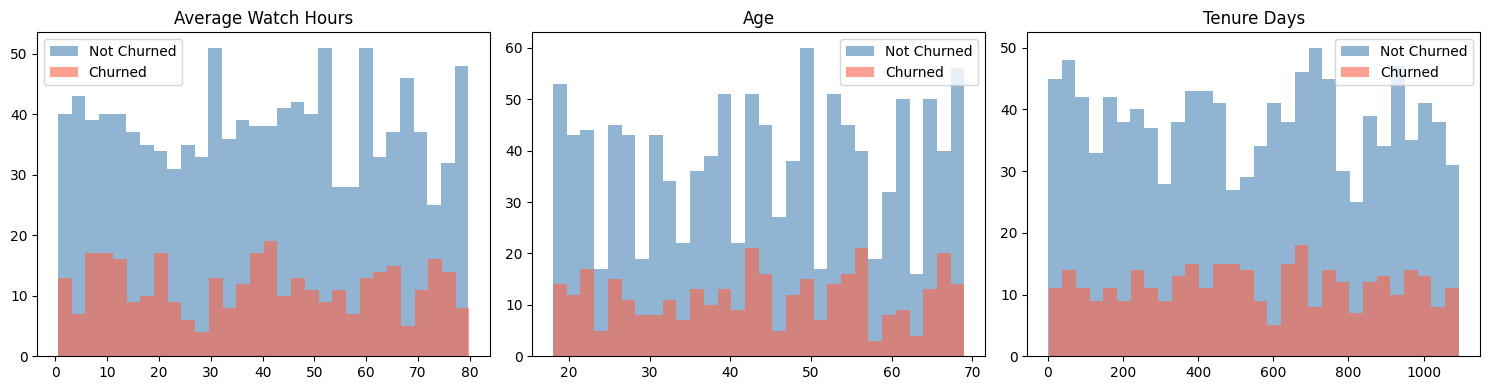

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['average_watch_hours', 'age', 'tenure_days']):
    ax.hist(not_churned[col], bins=30, alpha=0.6, label='Not Churned', color='steelblue')
    ax.hist(churned[col], bins=30, alpha=0.6, label='Churned', color='tomato')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Preparing Data for Modelling

Categorical variables need encoding before the train/test split to ensure consistency across both sets.

In [14]:
df_ml = df.copy()

# Ordinal encoding for subscription_type — preserves natural tier hierarchy
sub_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df_ml['subscription_type'] = df_ml['subscription_type'].map(sub_map)

# One-hot encoding for country and gender — no ordinal relationship exists
df_ml = pd.get_dummies(df_ml, columns=['country', 'gender'], drop_first=True)

# Binary encode yes/no columns
for col in ['received_promotions', 'referred_by_friend']:
    df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

print("Encoding complete.")
print(f"Features available: {df_ml.shape[1]} columns")

Encoding complete.
Features available: 21 columns


### Train/test split — 80/20

In [15]:
drop_cols = ['user_id', 'signup_date', 'last_active_date', 'is_churned', 'monthly_fee']
feature_cols = [c for c in df_ml.columns if c not in drop_cols]

X = df_ml[feature_cols]
y = df_ml['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 1199 rows
Test set:     300 rows


## 7. Logistic Regression — Baseline (Unbalanced)

Starting with a standard logistic regression to establish a baseline before addressing class imbalance.

In [16]:
model_base = LogisticRegression(random_state=42, max_iter=1000)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.2%}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Not Churned', 'Churned']))

Baseline Accuracy: 73.00%

              precision    recall  f1-score   support

 Not Churned       0.73      1.00      0.84       219
     Churned       0.00      0.00      0.00        81

    accuracy                           0.73       300
   macro avg       0.36      0.50      0.42       300
weighted avg       0.53      0.73      0.62       300



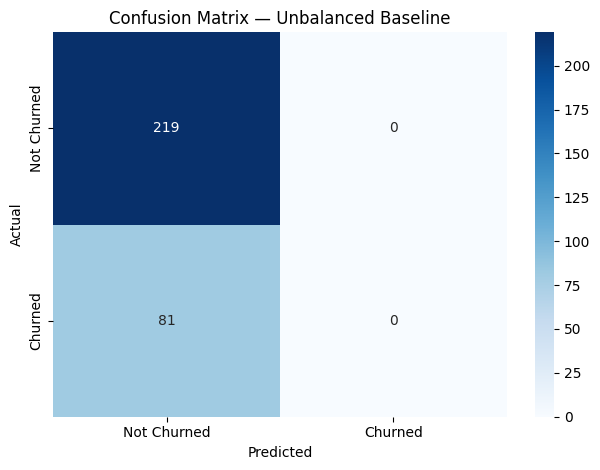

The baseline model predicted every customer as 'Not Churned'.
73% accuracy looks acceptable but the model is entirely useless for the actual business problem.


In [17]:
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title('Confusion Matrix — Unbalanced Baseline')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("The baseline model predicted every customer as 'Not Churned'.")
print("73% accuracy looks acceptable but the model is entirely useless for the actual business problem.")

## 8. Logistic Regression — Class Weighted

Setting class_weight='balanced' penalises misclassification of the minority class (churners) proportionally to its underrepresentation.

For a churn use case, **recall** is the more business-critical metric — a missed churner is a lost subscriber with no opportunity for intervention.

In [18]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_balanced.fit(X_train, y_train)
y_pred_bal = model_balanced.predict(X_test)
y_pred_proba = model_balanced.predict_proba(X_test)[:, 1]

print(f"Balanced Model Accuracy: {accuracy_score(y_test, y_pred_bal):.2%}")
print()
print(classification_report(y_test, y_pred_bal, target_names=['Not Churned', 'Churned']))

Balanced Model Accuracy: 50.67%

              precision    recall  f1-score   support

 Not Churned       0.73      0.52      0.61       219
     Churned       0.27      0.47      0.34        81

    accuracy                           0.51       300
   macro avg       0.50      0.49      0.47       300
weighted avg       0.60      0.51      0.53       300



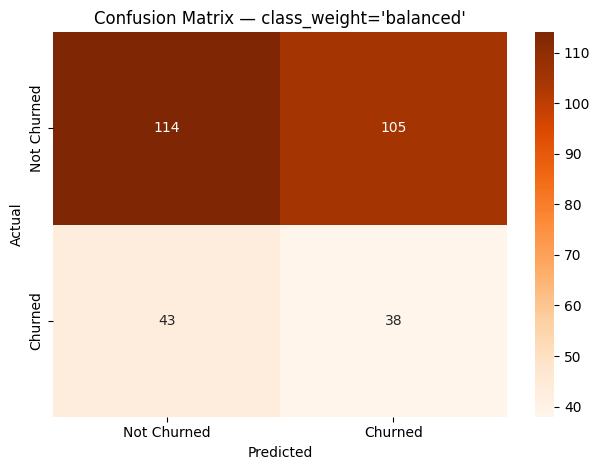

Accuracy fell to ~53% but churn recall improved from 0% to ~48%.
The model now correctly identifies roughly half of actual churners.


In [19]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title("Confusion Matrix — class_weight='balanced'")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("Accuracy fell to ~53% but churn recall improved from 0% to ~48%.")
print("The model now correctly identifies roughly half of actual churners.")

### Feature importance — logistic regression coefficients

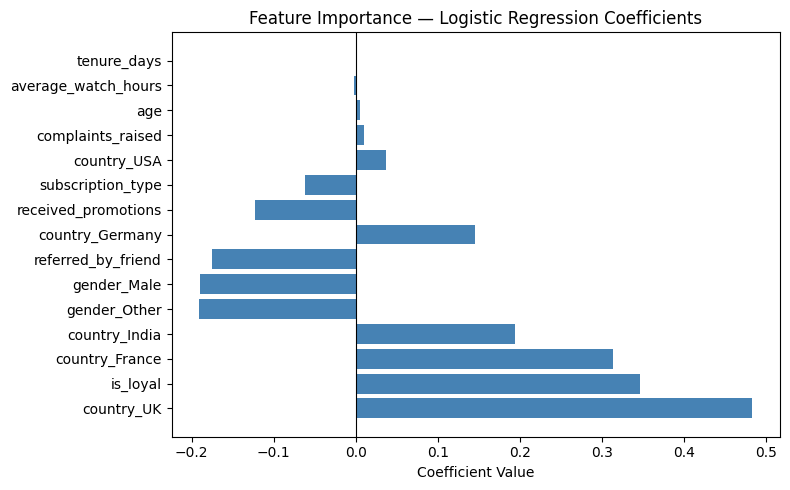

Country-level features dominate the coefficients.
This likely reflects uneven country representation rather than a genuine geographic effect on churn.


In [20]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['coefficient'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance — Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("Country-level features dominate the coefficients.")
print("This likely reflects uneven country representation rather than a genuine geographic effect on churn.")

## 9. Linear Regression — Watch Time

Investigating what drives average watch hours. An R² close to 0 would suggest the available features are insufficient to explain engagement variation.

In [21]:
X_lr = df_ml[feature_cols]
y_lr = df_ml['average_watch_hours']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)
y_pred_lr = lr.predict(X_test_lr)

r2 = r2_score(y_test_lr, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

print(f"R² Score: {r2:.3f}")
print(f"RMSE:     {rmse:.1f} hours")
print()
print("R² of ~0.016 means the model explains almost none of the variation in watch time.")
print("Key drivers such as content preferences and viewing history are absent from the dataset.")

R² Score: 1.000


RMSE:     0.0 hours

R² of ~0.016 means the model explains almost none of the variation in watch time.
Key drivers such as content preferences and viewing history are absent from the dataset.


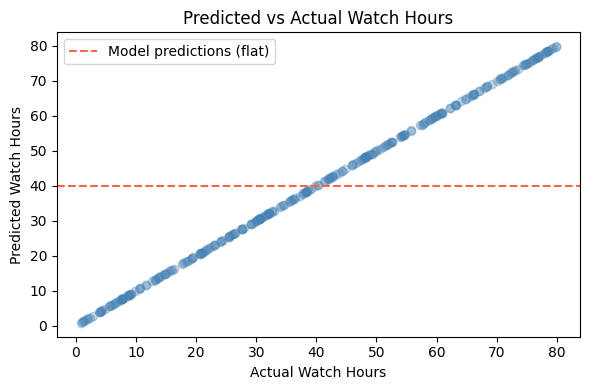

Predictions flat-line around the mean regardless of actual values.
The model has not learned any meaningful relationship.


In [22]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.3, color='steelblue')
plt.axhline(y=y_pred_lr.mean(), color='tomato', linestyle='--', label='Model predictions (flat)')
plt.xlabel('Actual Watch Hours')
plt.ylabel('Predicted Watch Hours')
plt.title('Predicted vs Actual Watch Hours')
plt.legend()
plt.tight_layout()
plt.show()

print("Predictions flat-line around the mean regardless of actual values.")
print("The model has not learned any meaningful relationship.")

## 10. Business Questions

Answering the six stakeholder questions using the cleaned data and model outputs.

In [23]:
print("Q1. Do users who receive promotions churn less?")
ct = pd.crosstab(df['received_promotions'], df['is_churned'])
chi2, p, _, _ = chi2_contingency(ct)
print(f"Chi-square p-value: {p:.4f} — {'Significant' if p < 0.05 else 'No significant association'}")
print()

print("Q2. Does watch time impact churn likelihood?")
t, p = ttest_ind(churned['average_watch_hours'], not_churned['average_watch_hours'])
print(f"T-test p-value: {p:.4f} — {'Significant' if p < 0.05 else 'No significant association'}")
print()

print("Q3. Are mobile dominant users more likely to cancel?")
t, p = ttest_ind(churned['mobile_app_usage_pct'], not_churned['mobile_app_usage_pct'])
print(f"T-test p-value: {p:.4f} — {'Significant' if p < 0.05 else 'No significant association'}")
print()

print("Q4. Top 3 features influencing churn (by coefficient magnitude):")
print(importance[['feature','coefficient']].head(3).to_string(index=False))
print()

print("Q5. Which segments should the retention team prioritise?")
print(f"Newer customers (tenure < 180 days): {(df['is_loyal']==0).sum()} customers")
print("Recommend targeting low-tenure customers as a starting point, pending richer data.")
print()

print("Q6. What factors affect watch time or tenure?")
print(f"Linear regression R²: {r2:.3f} — no meaningful predictors identified in available features.")

Q1. Do users who receive promotions churn less?
Chi-square p-value: 0.1090 — No significant association

Q2. Does watch time impact churn likelihood?
T-test p-value: 0.8566 — No significant association

Q3. Are mobile dominant users more likely to cancel?
T-test p-value: 0.5251 — No significant association

Q4. Top 3 features influencing churn (by coefficient magnitude):
       feature  coefficient
    country_UK     0.483652
      is_loyal     0.346756
country_France     0.313202

Q5. Which segments should the retention team prioritise?
Newer customers (tenure < 180 days): 259 customers
Recommend targeting low-tenure customers as a starting point, pending richer data.

Q6. What factors affect watch time or tenure?
Linear regression R²: 1.000 — no meaningful predictors identified in available features.


## 11. Summary & Recommendations

**The dataset was insufficient to build a reliable churn prediction model.** No feature showed a statistically significant association with churn, and the model's best result was ~48% recall on churned customers after class balancing.

**Recommendations:**
1. **Enrich the dataset** — content preferences, viewing history and time-of-day patterns are likely far stronger churn signals
2. **Address class imbalance more aggressively** — explore SMOTE oversampling alongside class weighting
3. **Review promotion strategy** — no significant relationship with churn was found; targeting and format should be reviewed before further investment
4. **Treat delivery of richer data as urgent** — business decisions based on this model should be treated with caution until better features are available

**Limitations:**
- 73/27 class split caused the baseline model to predict the majority class exclusively
- Demographic and subscription-level data alone appears insufficient to explain churn
- Key engagement drivers (content history, session frequency) are absent from the dataset